#  A3 – Comitê de Classificadores: Wine Quality
## Etapa 1: Exploração e Análise dos Dados (EDA)

## 1. Importação das bibliotecas

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

## 2. Carregamento do Dataset

In [ ]:
df = pd.read_csv('WineQT.csv')
print(f'Linhas: {df.shape[0]} | Colunas: {df.shape[1]}')

Linhas: 1143 | Colunas: 13


## 3. Primeiras linhas do dataset

In [ ]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


## 4. Informações gerais das colunas

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


## 5. Verificação de valores faltantes

In [ ]:
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


## 6. Estatísticas básicas

In [ ]:
df.describe().round(2)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.00,1143.00,1143.00,1143.00,1143.00,1143.00,1143.00,1143.00,1143.00,1143.00,1143.00,1143.00,1143.00
mean,8.31,0.53,0.27,2.53,0.09,15.62,45.91,1.00,3.31,0.66,10.44,5.66,804.97
std,1.75,0.18,0.20,1.36,0.05,10.25,32.78,0.00,0.16,0.17,1.08,0.81,464.00
min,4.60,0.12,0.00,0.90,0.01,1.00,6.00,0.99,2.74,0.33,8.40,3.00,0.00
25%,7.10,0.39,0.09,1.90,0.07,7.00,21.00,1.00,3.20,0.55,9.50,5.00,411.00
50%,7.90,0.52,0.25,2.20,0.08,13.00,37.00,1.00,3.31,0.62,10.20,6.00,794.00
75%,9.10,0.64,0.42,2.60,0.09,21.00,61.00,1.00,3.40,0.73,11.10,6.00,1209.50
max,15.90,1.58,1.00,15.50,0.61,68.00,289.00,1.00,4.01,2.00,14.90,8.00,1597.00


## 7. Distribuição da variável target (quality)

/tmp/ipykernel_26553/1200345728.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='quality', palette='Reds_r')


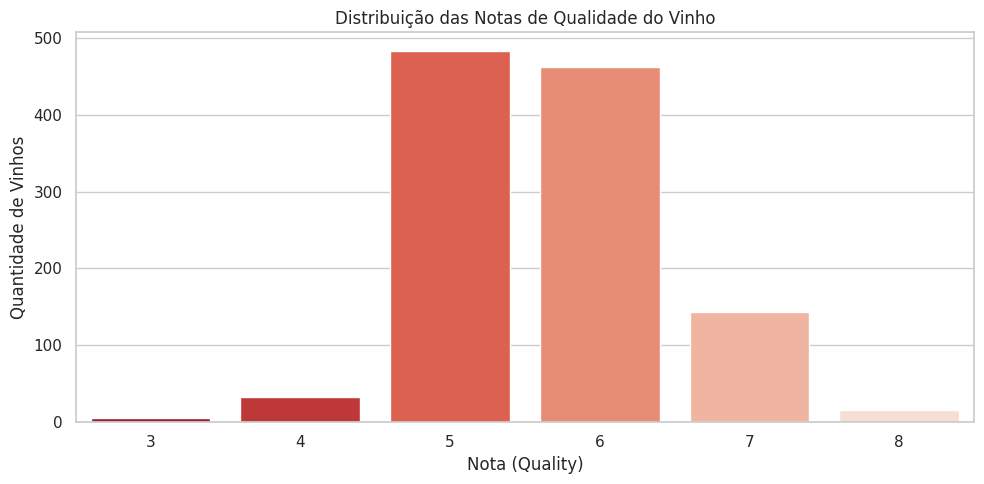

In [ ]:
sns.countplot(data=df, x='quality', palette='Reds_r')
plt.title('Distribuição das Notas de Qualidade do Vinho')
plt.xlabel('Nota (Quality)')
plt.ylabel('Quantidade de Vinhos')
plt.tight_layout()
plt.show()

## 8. Distribuição das features

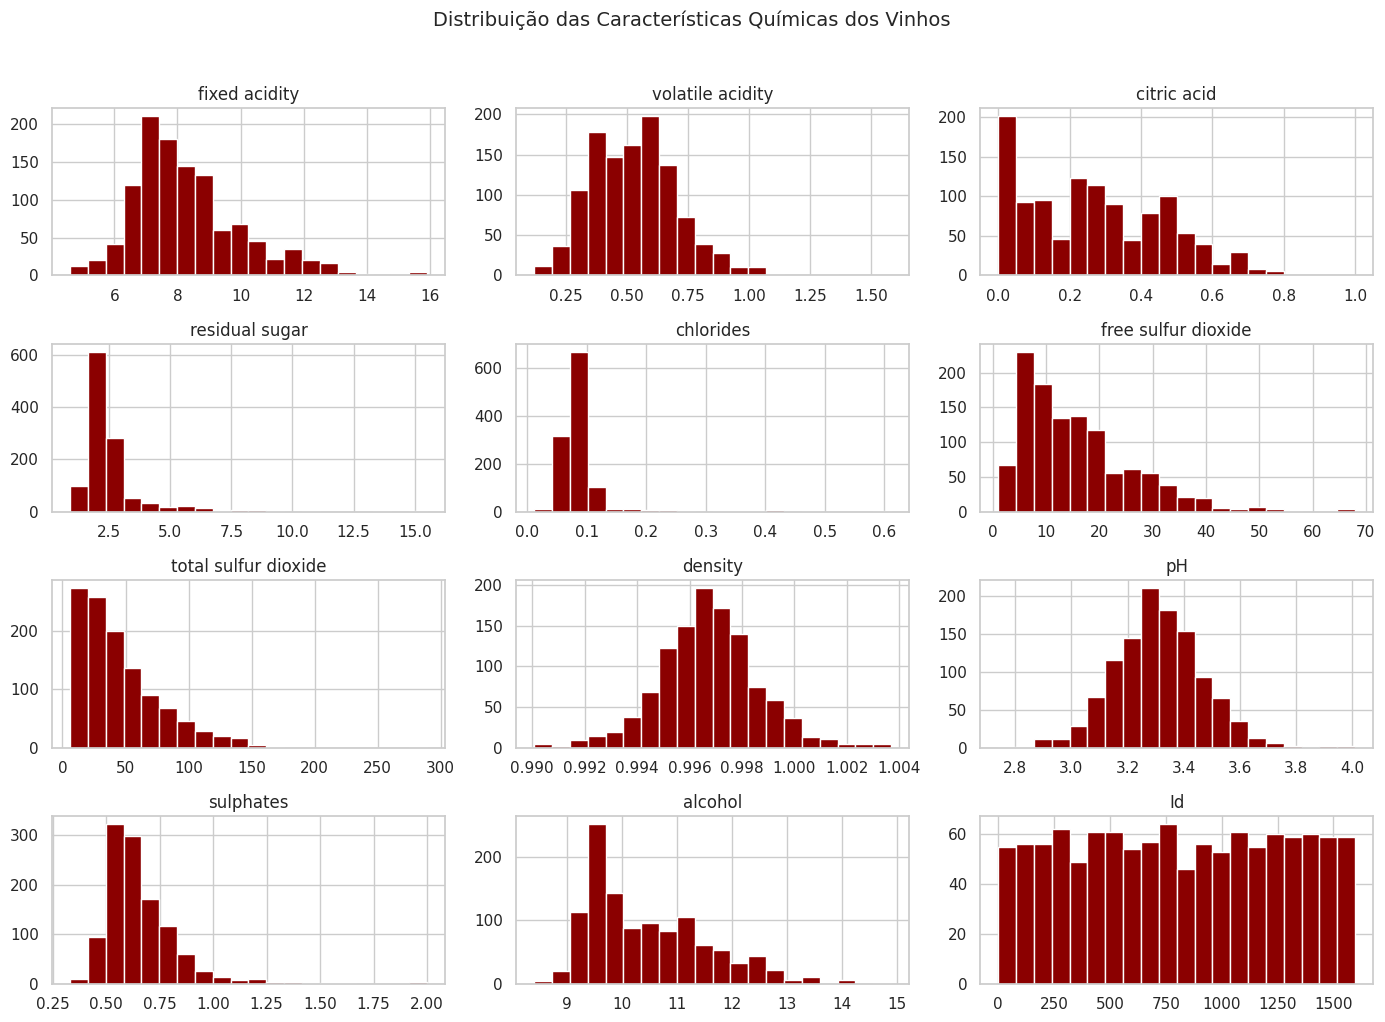

In [ ]:
df.drop(columns=['quality']).hist(bins=20, figsize=(14, 10), color='darkred', edgecolor='white')
plt.suptitle('Distribuição das Características Químicas dos Vinhos', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 9. Correlação entre as variáveis

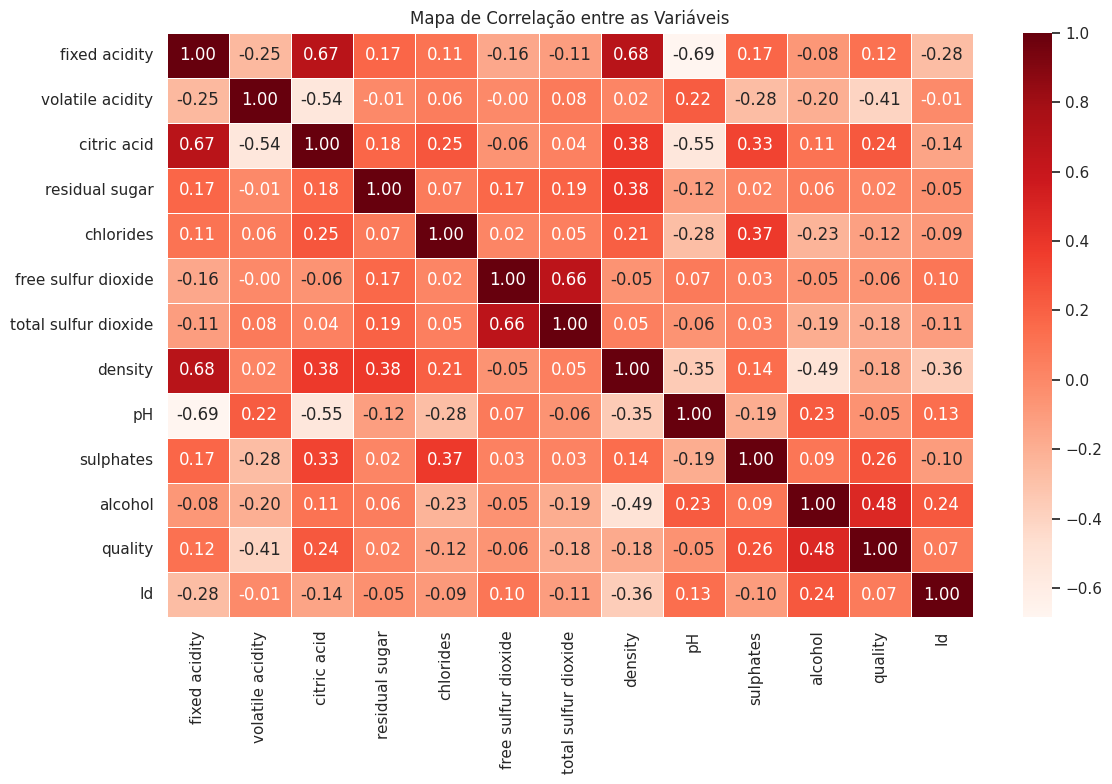

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='Reds', linewidths=0.5)
plt.title('Mapa de Correlação entre as Variáveis')
plt.tight_layout()
plt.show()

## 10. Relação entre álcool e qualidade

/tmp/ipykernel_26553/648324335.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='quality', y='alcohol', palette='Reds_r')


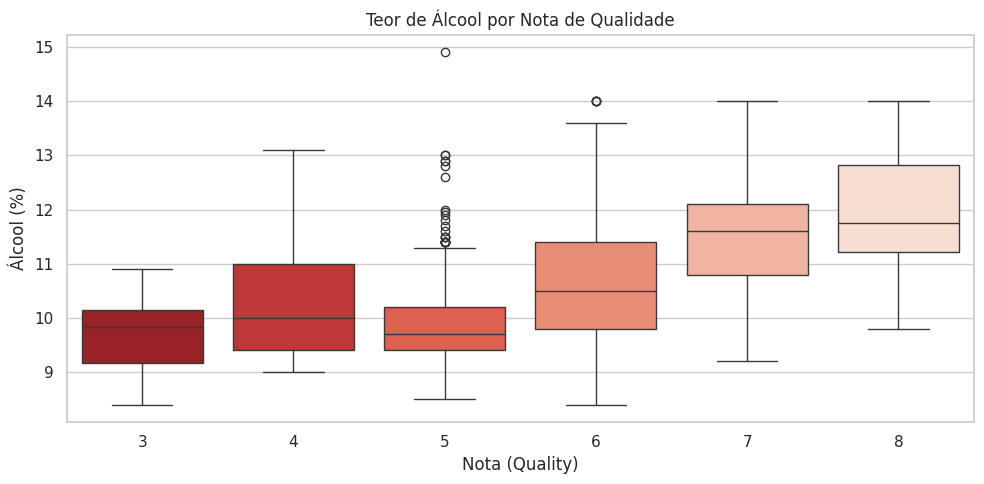

In [ ]:
sns.boxplot(data=df, x='quality', y='alcohol', palette='Reds_r')
plt.title('Teor de Álcool por Nota de Qualidade')
plt.xlabel('Nota (Quality)')
plt.ylabel('Álcool (%)')
plt.tight_layout()
plt.show()

## 11. Análise do desbalanceamento

In [ ]:
percentual = (df['quality'].value_counts(normalize=True) * 100).sort_index().round(2)
for nota, perc in percentual.items():
    barra = '█' * int(perc)
    print(f'Nota {nota}: {barra} {perc}%')

Nota 3:  0.52%
Nota 4: ██ 2.89%
Nota 5: ██████████████████████████████████████████ 42.26%
Nota 6: ████████████████████████████████████████ 40.42%
Nota 7: ████████████ 12.51%
Nota 8: █ 1.4%
